# Automobile Data Analysis and Preprocessing

This notebook analyzes the 1985 Automobile Imports Database, which consists of various attributes of different car models. We'll load the data, preprocess it, and perform exploratory data analysis to prepare it for machine learning algorithms.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_style('whitegrid')  
plt.rcParams['figure.figsize'] = (12, 8)

## Loading the Data

Based on the metadata in `imports-85.names`, we know this dataset has 26 attributes. Let's define the column names and load the data.

In [5]:
# Define column names from the metadata file
columns = ['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
           'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
           'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
           'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
           'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Load the data
data = pd.read_csv('../data/imports-85.data', header=None, names=columns)

# Display first few rows
data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## Initial Data Exploration

In [6]:
# Check data shape
print(f"Dataset shape: {data.shape}")

# Data types
print("\nData types:")
print(data.dtypes)

# Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())

Dataset shape: (205, 26)

Data types:
symboling              int64
normalized-losses     object
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                  object
stroke                object
compression-ratio    float64
horsepower            object
peak-rpm              object
city-mpg               int64
highway-mpg            int64
price                 object
dtype: object

Missing values per column:
symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive

In [7]:
# Replace '?' with NaN
data = data.replace('?', np.nan)

# Check missing values again
print("Missing values per column after replacing '?' with NaN:")
print(data.isnull().sum())

Missing values per column after replacing '?' with NaN:
symboling             0
normalized-losses    41
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  4
stroke                4
compression-ratio     0
horsepower            2
peak-rpm              2
city-mpg              0
highway-mpg           0
price                 4
dtype: int64


In [8]:
# Statistical summary
data.describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
wheel-base,205.0,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9
length,205.0,174.049268,12.337289,141.1,166.3,173.2,183.1,208.1
width,205.0,65.907805,2.145204,60.3,64.1,65.5,66.9,72.3
height,205.0,53.724878,2.443522,47.8,52.0,54.1,55.5,59.8
curb-weight,205.0,2555.565854,520.680204,1488.0,2145.0,2414.0,2935.0,4066.0
engine-size,205.0,126.907317,41.642693,61.0,97.0,120.0,141.0,326.0
compression-ratio,205.0,10.142537,3.972040,7.0,8.6,9.0,9.4,23.0
city-mpg,205.0,25.219512,6.542142,13.0,19.0,24.0,30.0,49.0
highway-mpg,205.0,30.751220,6.886443,16.0,25.0,30.0,34.0,54.0


## Data Preprocessing

### Converting Data Types

We need to convert several columns to their appropriate data types.

In [9]:
# Numeric columns that need to be converted
numeric_cols = ['normalized-losses', 'wheel-base', 'length', 'width', 'height',
                'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio',
                'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'price']

# Convert to numeric
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Check data types again
print("Data types after conversion:")
print(data.dtypes)

Data types after conversion:
symboling              int64
normalized-losses    float64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
dtype: object


### Handling Missing Values

In [10]:
# Calculate percentage of missing values
missing_percentage = data.isnull().sum() / len(data) * 100

# Create a dataframe to display columns with missing values
missing_data = pd.DataFrame({'Column': data.columns,
                            'Missing Value Count': data.isnull().sum(),
                            'Missing Percentage': missing_percentage})

# Sort by percentage of missing values
missing_data = missing_data.sort_values('Missing Percentage', ascending=False)
missing_data = missing_data[missing_data['Missing Value Count'] > 0]
missing_data

,Column,Missing Value Count,Missing Percentage
normalized-losses,normalized-losses,41,20.00000
stroke,stroke,4,1.95122
price,price,4,1.95122
bore,bore,4,1.95122
horsepower,horsepower,2,0.97561
peak-rpm,peak-rpm,2,0.97561
num-of-doors,num-of-doors,2,0.97561


In [11]:
# Impute missing values
# For numeric columns, use median
numeric_imputer = SimpleImputer(strategy='median')
data[numeric_cols] = numeric_imputer.fit_transform(data[numeric_cols])

# For categorical columns with missing values, use most frequent value
cat_cols = ['num-of-doors']
cat_imputer = SimpleImputer(strategy='most_frequent')
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

# Check if there are still missing values
print("Missing values after imputation:")
print(data.isnull().sum().sum())

Missing values after imputation:
0


## Exploratory Data Analysis (EDA)

### Distribution of Continuous Variables

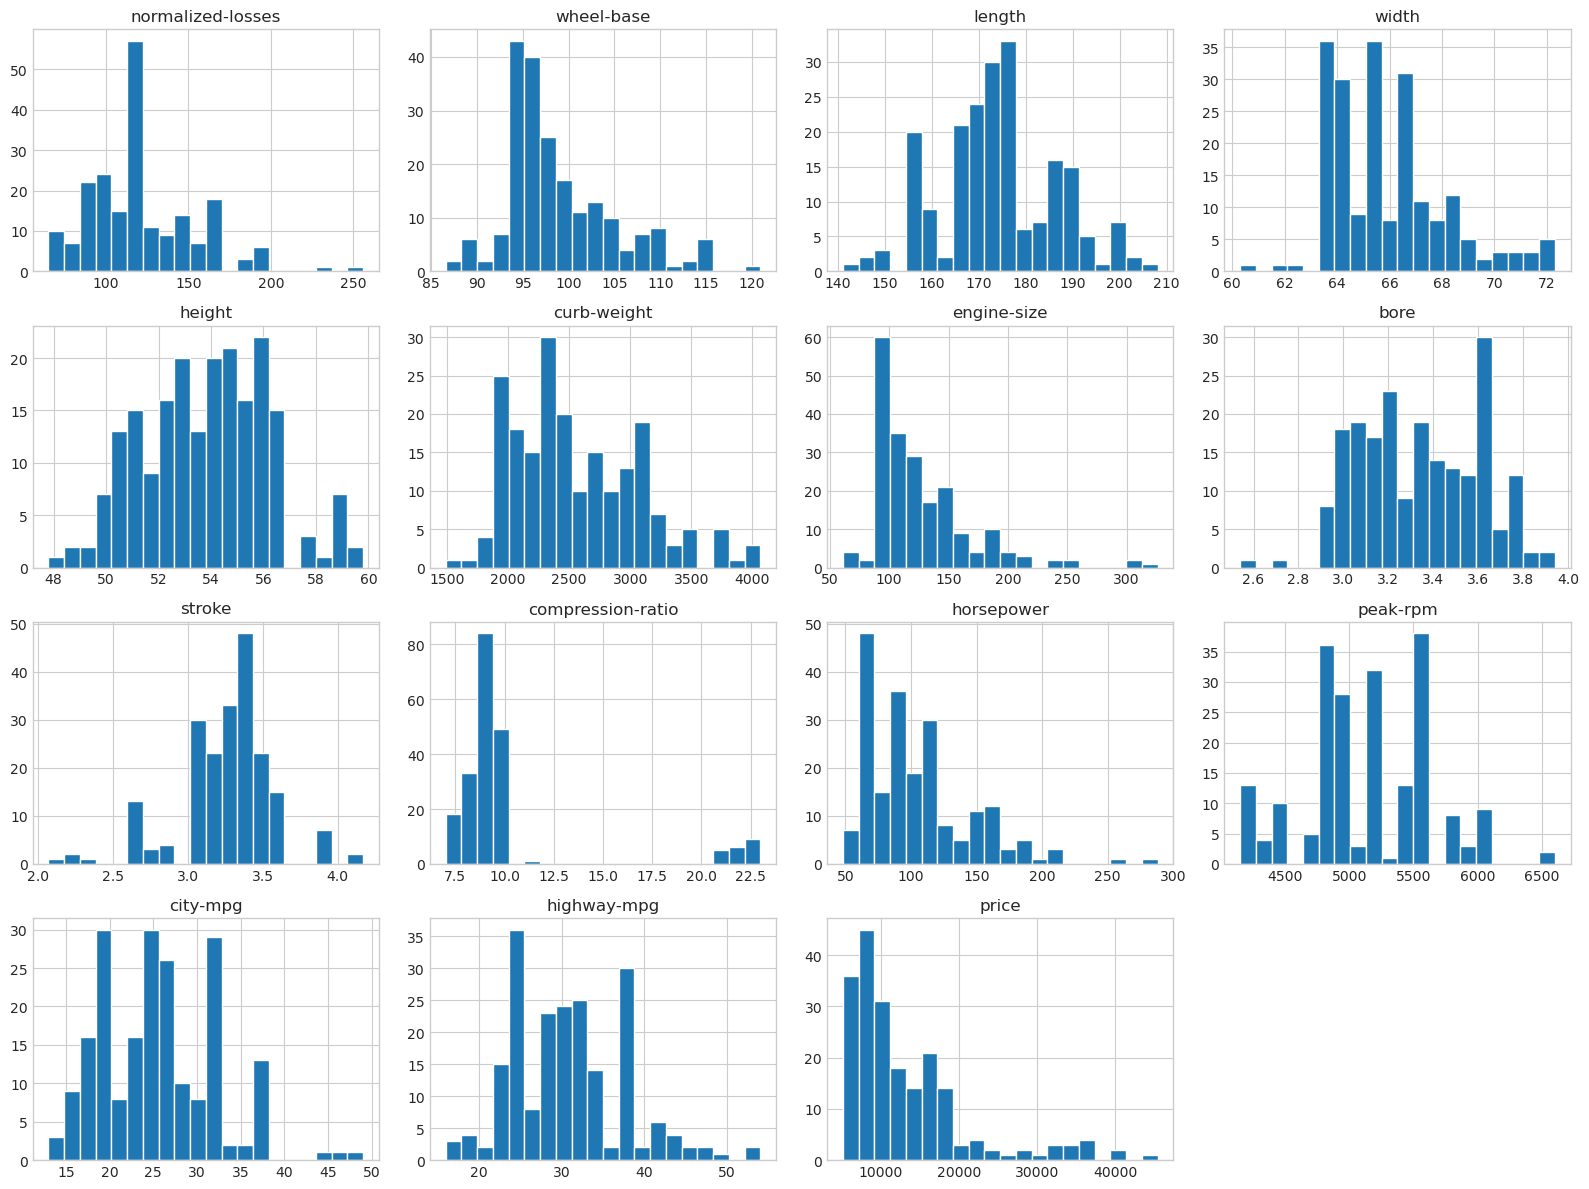

In [12]:
# Histogram of all numeric variables
data[numeric_cols].hist(figsize=(16, 12), bins=20)
plt.tight_layout()
plt.show()

### Car Makes Analysis

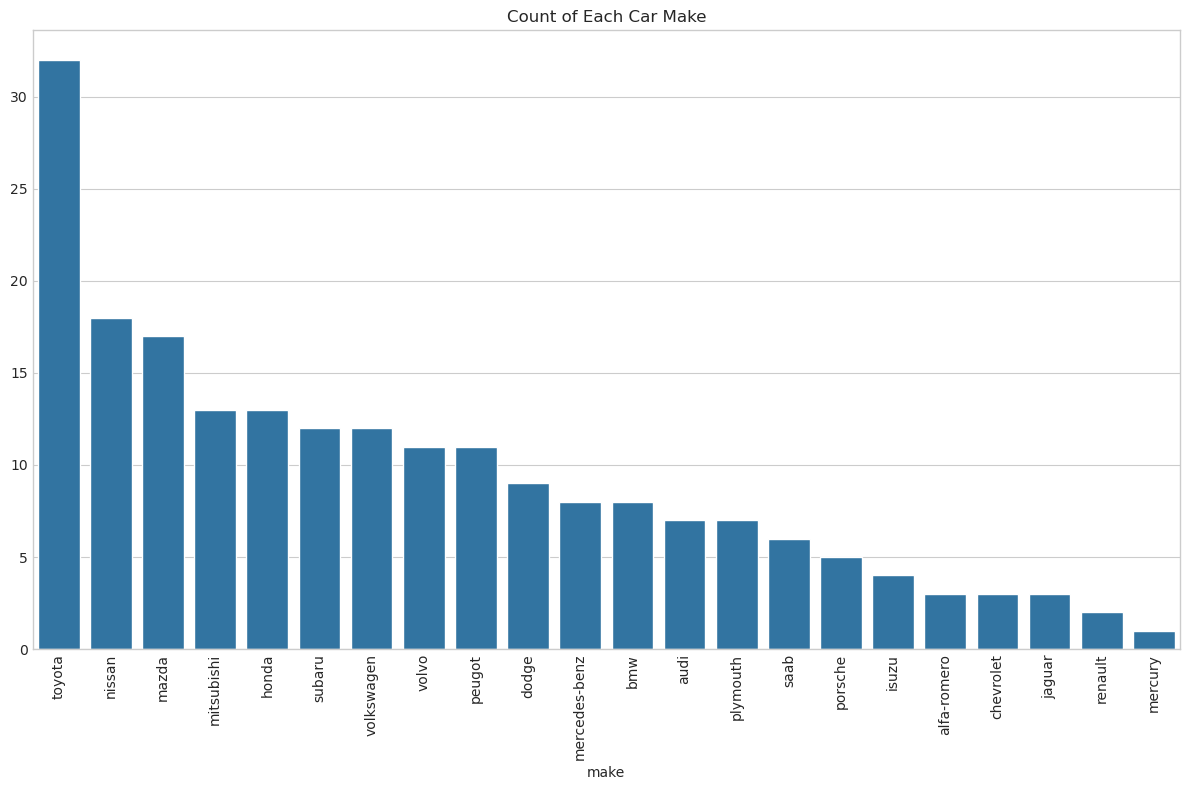

In [13]:
# Count of each car make
plt.figure(figsize=(12, 8))
count_make = data['make'].value_counts()
sns.barplot(x=count_make.index, y=count_make.values)
plt.title('Count of Each Car Make')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

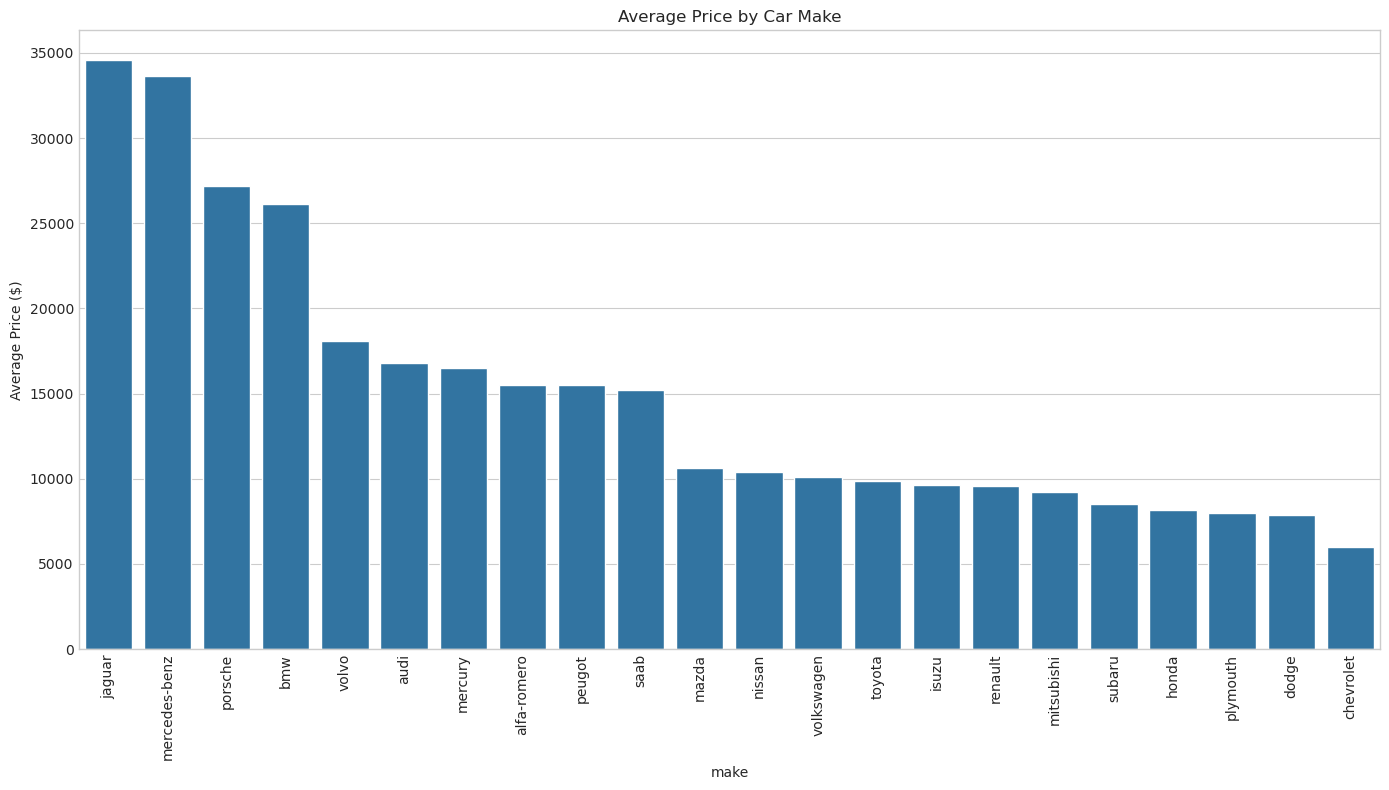

In [14]:
# Average price by make
plt.figure(figsize=(14, 8))
avg_price = data.groupby('make')['price'].mean().sort_values(ascending=False)
sns.barplot(x=avg_price.index, y=avg_price.values)
plt.title('Average Price by Car Make')
plt.xticks(rotation=90)
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

### Price Analysis

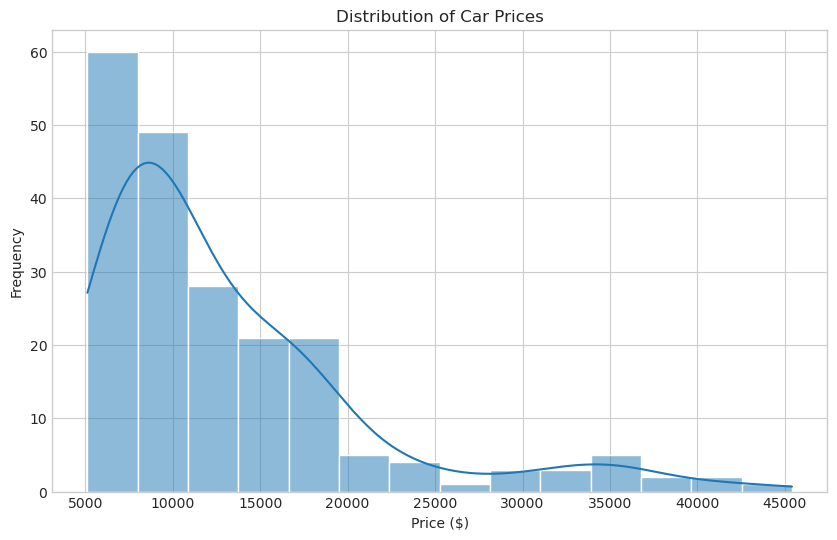

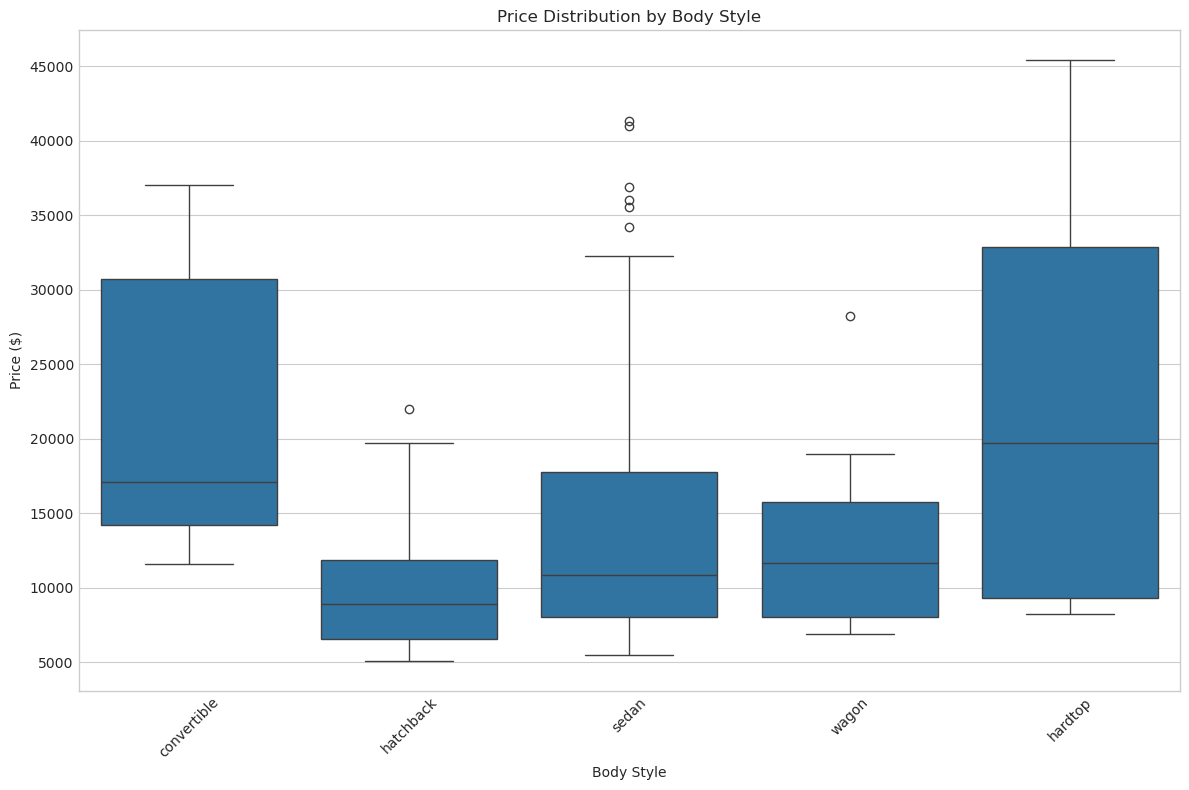

In [15]:
# Distribution of Price
plt.figure(figsize=(10, 6))
sns.histplot(data['price'], kde=True)
plt.title('Distribution of Car Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# Box plot of price by body style
plt.figure(figsize=(12, 8))
sns.boxplot(x='body-style', y='price', data=data)
plt.title('Price Distribution by Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Correlation Analysis

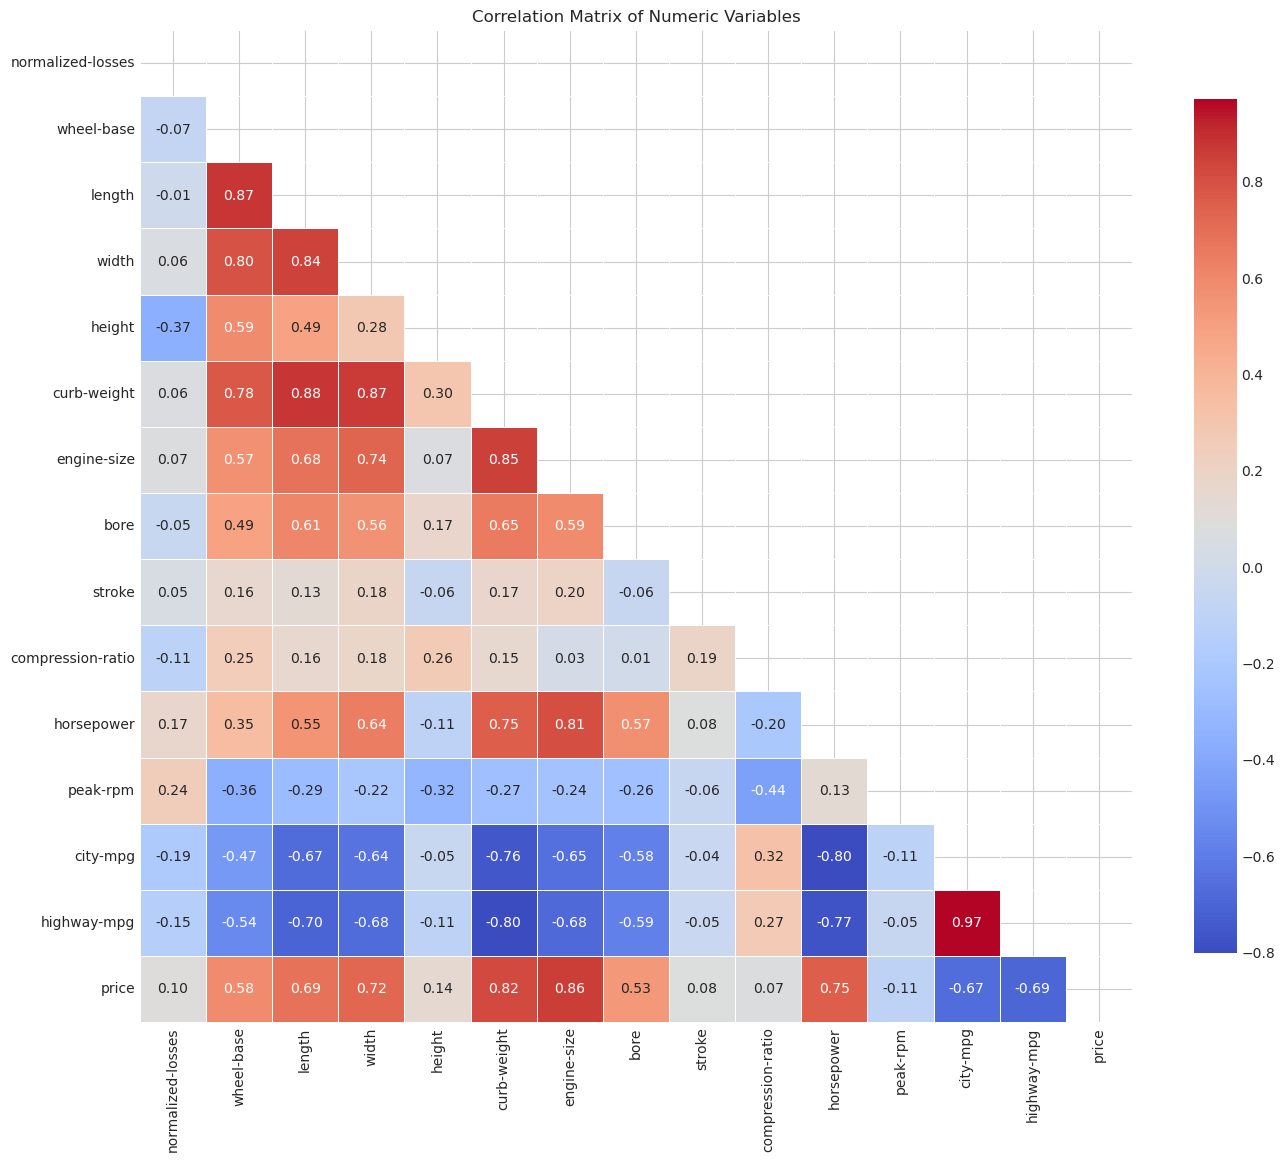

In [16]:
# Calculate correlation matrix for numeric variables
corr_matrix = data[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=.5, cbar_kws={'shrink': .8})
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()

### Key Feature Relationships

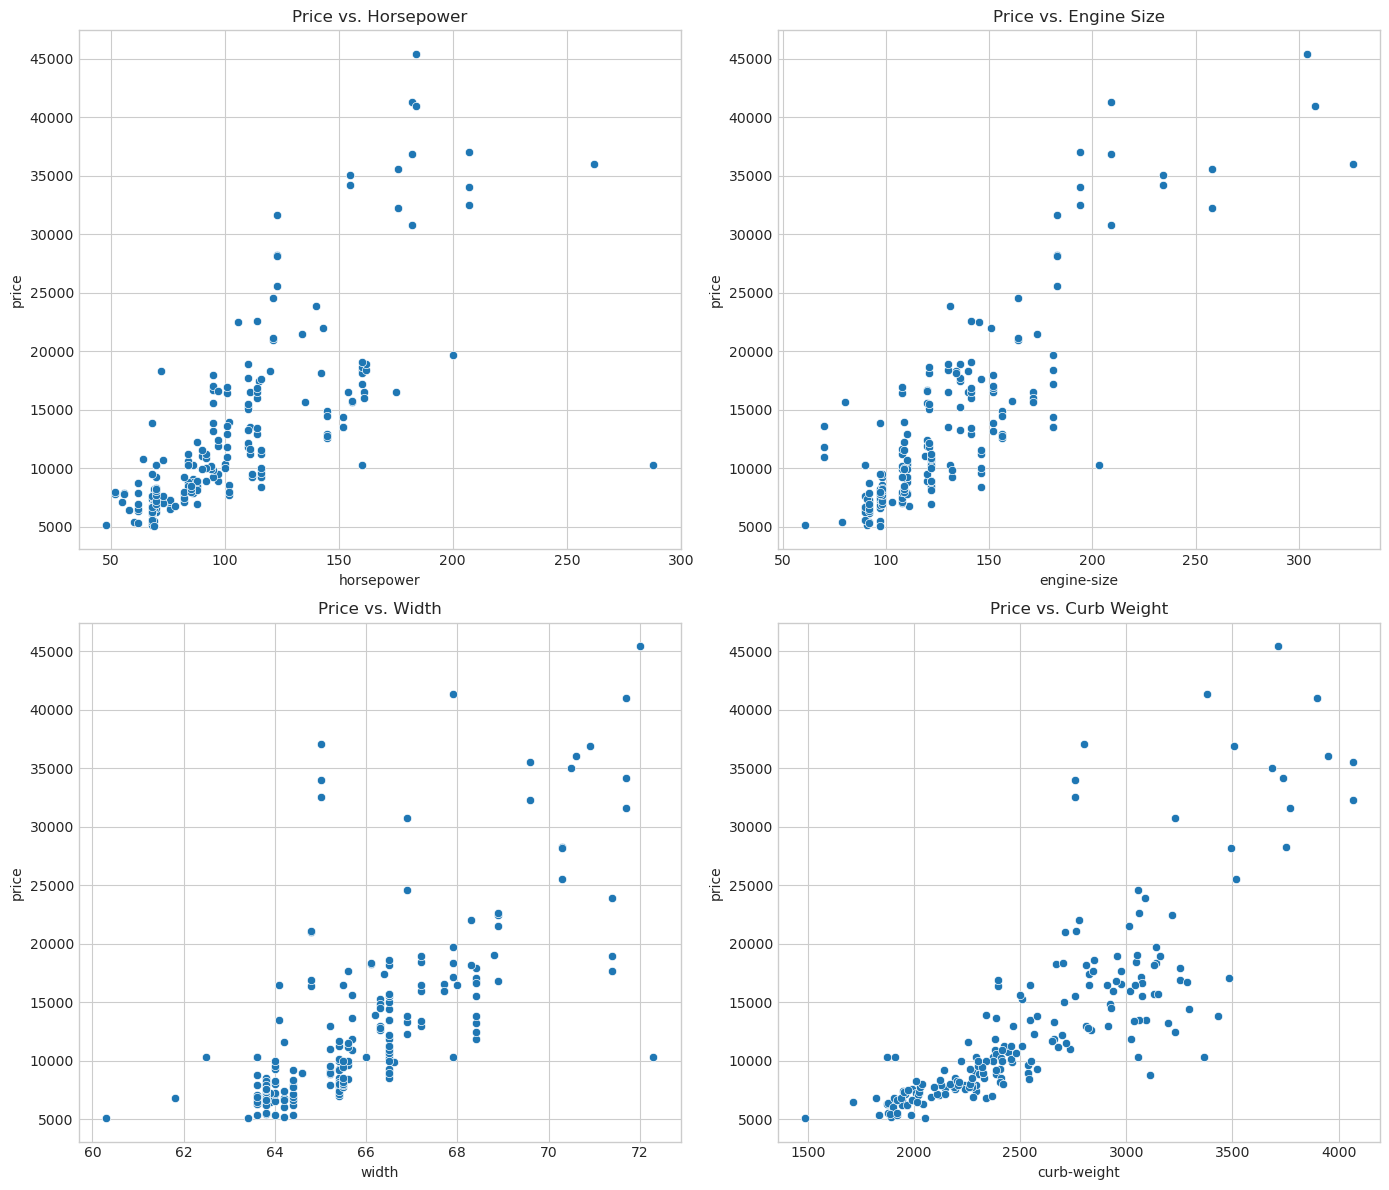

In [17]:
# Scatter plots for key feature relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Price vs. horsepower
sns.scatterplot(x='horsepower', y='price', data=data, ax=axes[0, 0])
axes[0, 0].set_title('Price vs. Horsepower')

# Price vs. engine-size
sns.scatterplot(x='engine-size', y='price', data=data, ax=axes[0, 1])
axes[0, 1].set_title('Price vs. Engine Size')

# Price vs. width
sns.scatterplot(x='width', y='price', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Price vs. Width')

# Price vs. curb-weight
sns.scatterplot(x='curb-weight', y='price', data=data, ax=axes[1, 1])
axes[1, 1].set_title('Price vs. Curb Weight')

plt.tight_layout()
plt.show()

### Specific Analysis of Width and Horsepower

Based on the 'misc' file, there seems to be a special interest in the relationship between width and horsepower.

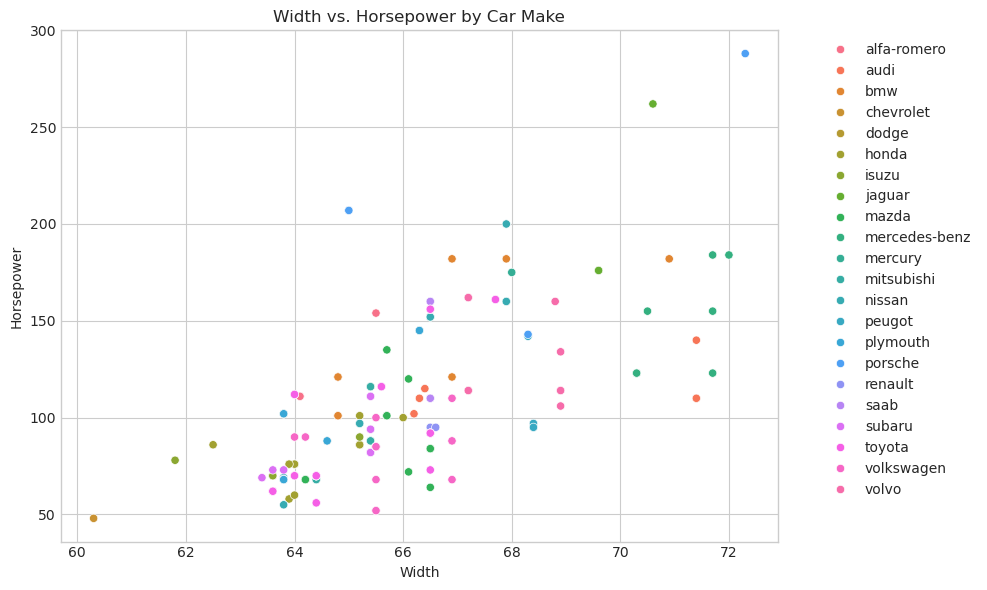

In [18]:
# Scatter plot with width and horsepower
plt.figure(figsize=(10, 6))
sns.scatterplot(x='width', y='horsepower', data=data, hue='make')
plt.title('Width vs. Horsepower by Car Make')
plt.xlabel('Width')
plt.ylabel('Horsepower')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

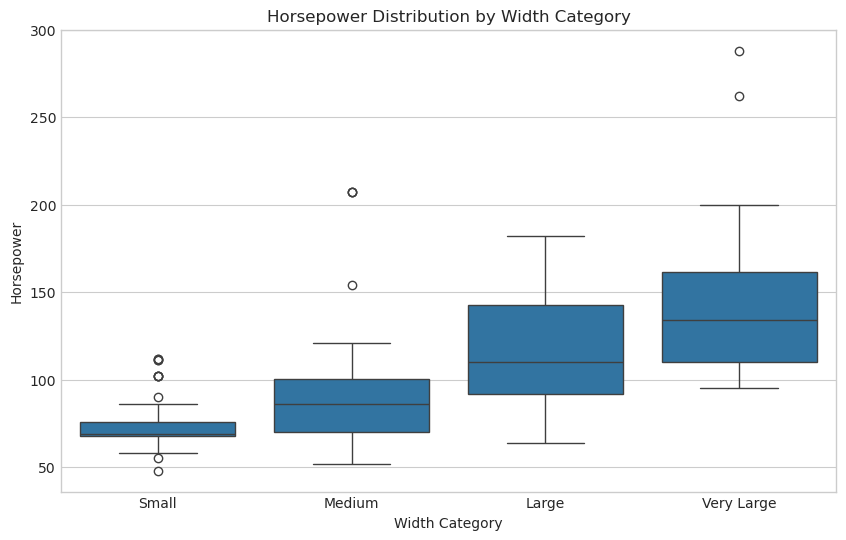

In [19]:
# Compare horsepower across different width ranges
data['width_category'] = pd.qcut(data['width'], 4, labels=['Small', 'Medium', 'Large', 'Very Large'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='width_category', y='horsepower', data=data)
plt.title('Horsepower Distribution by Width Category')
plt.xlabel('Width Category')
plt.ylabel('Horsepower')
plt.show()

## Feature Engineering

In [20]:
# Create a power-to-weight ratio feature
data['power_to_weight'] = data['horsepower'] / data['curb-weight']

# Create a feature for engine size per cylinder
# First, convert num-of-cylinders to numeric
cylinder_map = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}
data['num_cylinders'] = data['num-of-cylinders'].map(cylinder_map)
data['engine_size_per_cylinder'] = data['engine-size'] / data['num_cylinders']

# Create fuel efficiency feature (combined MPG)
data['combined_mpg'] = (data['city-mpg'] + data['highway-mpg']) / 2

# Display new features
data[['power_to_weight', 'engine_size_per_cylinder', 'combined_mpg']].describe()

,power_to_weight,engine_size_per_cylinder,combined_mpg
count,205.000000,205.000000,205.000000
mean,0.040082,28.841911,27.985366
std,0.009563,5.056321,6.666038
min,0.019936,19.750000,15.000000
25%,0.034188,24.500000,22.500000
50%,0.037811,27.500000,27.000000
75%,0.044489,32.333333,32.000000
max,0.085561,43.000000,51.500000


## Preparing for ML

In [25]:
# Note in case you are willing to use categories instead
# just create another copy of the original dataframe 
# and make sure to re-split the data into train and test sets

In [26]:
# In case you want to use a validation set, split the training set
# into a training and validation set 
# X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [27]:
# In case there is something interresting in the data or a pattern you want to work on just add another notebook

In [21]:
# Encoding categorical variables
categorical_cols = ['make', 'fuel-type', 'aspiration', 'num-of-doors', 
                    'body-style', 'drive-wheels', 'engine-location',
                    'engine-type', 'num-of-cylinders', 'fuel-system']

# Create a copy of the data for ML preparation
ml_data = data.copy()

# Apply one-hot encoding to categorical columns
ml_data = pd.get_dummies(ml_data, columns=categorical_cols, drop_first=True)

# Drop unnecessary columns
ml_data.drop(['width_category'], axis=1, inplace=True)

In [22]:
# Display shape of prepared data
print(f"Shape of data prepared for ML: {ml_data.shape}")

# Display sample of prepared data
ml_data.head()

Shape of data prepared for ML: (205, 70)


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_three,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,115.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,3,115.0,88.6,168.8,64.1,48.8,2548.0,130.0,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,1,115.0,94.5,171.2,65.5,52.4,2823.0,152.0,2.68,3.47,...,False,False,False,False,False,False,False,True,False,False
3,2,164.0,99.8,176.6,66.2,54.3,2337.0,109.0,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
4,2,164.0,99.4,176.6,66.4,54.3,2824.0,136.0,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


## Feature Scaling

In [23]:
# Identify numeric columns to scale
numeric_features = ml_data.select_dtypes(include=['float64', 'int64']).columns.tolist()

# If we were predicting price, we would remove it from features to scale
if 'price' in numeric_features:
    numeric_features.remove('price')

# Create a scaler
scaler = StandardScaler()

# Scale numeric features
ml_data[numeric_features] = scaler.fit_transform(ml_data[numeric_features])

# Display scaled data
ml_data.head()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_three,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,1.743470,-0.176503,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.520489,-1.841345,...,False,False,False,False,False,False,False,True,False,False
1,1.743470,-0.176503,-1.690772,-0.426521,-0.844782,-2.020417,-0.014566,0.074449,0.520489,-1.841345,...,False,False,False,False,False,False,False,True,False,False
2,0.133509,-0.176503,-0.708596,-0.231513,-0.190566,-0.543527,0.514882,0.604046,-2.403313,0.683683,...,False,False,False,False,False,False,False,True,False,False
3,0.938490,1.367901,0.173698,0.207256,0.136542,0.235942,-0.420797,-0.431076,-0.515795,0.459947,...,False,False,False,False,False,False,False,True,False,False
4,0.938490,1.367901,0.107110,0.207256,0.230001,0.235942,0.516807,0.218885,-0.515795,0.459947,...,False,False,False,False,False,False,False,True,False,False


## Data Splitting for ML

In [24]:
# Define features (X) and target (y) - assuming we're predicting 'price'
X = ml_data.drop('price', axis=1)
y = ml_data['price']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (164, 69)
Testing set shape: (41, 69)
